In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc


In [47]:
#specfem_datapath='../specfem3d_examples/homo_3d_topo/OUTPUT_FILES/'
specfem_datapath='./OUTPUT_FILES/'


In [48]:
# topo = m8r.Input(ewtop3d_datapath+'top.rsf')
# o1=topo.float('o1')
# d1=topo.float('d1')
# n1=topo.int('n1')
# o2=topo.float('o2')
# d2=topo.float('d2')
# n2=topo.int('n2')
# top = topo.read(shape=(n2,n1)).T

# top.shape
# top=1000*top+95
# rec_x = np.linspace(0,3000,61)
# rec_y = 1100*np.ones((61,1))

In [49]:
traceZ = pd.read_csv(specfem_datapath + "AA.S0096.BXZ.semv", 
                     header=None, 
                     sep="\s+",  # This allows multiple spaces/tabs
                     engine="python")


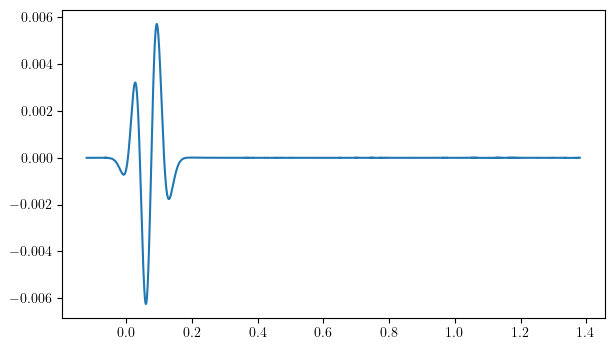

In [50]:
#traceZ = pd.read_csv(specfem_datapath+"CE.RX1500Y1000.FXZ.semv", header = None, skipinitialspace=True, delimiter=" ") 
plt.plot(traceZ[0],traceZ[1])

In [51]:
time=traceZ[0]

(3752, 3)


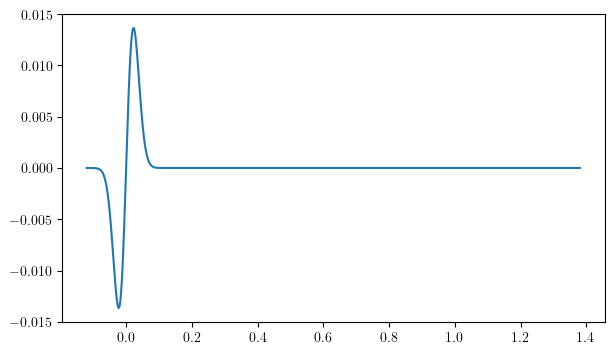

In [52]:
source =  np.loadtxt(specfem_datapath + "plot_source_time_function.txt", comments="#")
print(source.shape)
plt.plot(source[:,0],source[:,2])
t = source[:,0]

In [53]:
# t = traceZ[0].to_numpy()
# fq = 10
# t0 = t[-1]/2+1.196/fq
# source = (1-2*pi**2*fq**2*(t-t0)**2)*np.exp(-pi**2*fq**2*(t-t0)**2)
# plt.plot(t,source)

In [54]:
rec_x = range(1,202)
y=1100

k=0
dataX=np.zeros(shape=(np.size(time),np.size(rec_x)))
dataY=np.zeros(shape=(np.size(time),np.size(rec_x)))
dataZ=np.zeros(shape=(np.size(time),np.size(rec_x)))
for x in rec_x:
    filenameZ = specfem_datapath+'AA.S'+f"{x:04d}"+'.BXZ.semv'
    filenameX = specfem_datapath+'AA.S'+f"{x:04d}"+'.BXX.semv'
    traceX = pd.read_csv(filenameX, header=None, sep=r"\s+", engine="python")
    traceZ = pd.read_csv(filenameZ, header=None, sep=r"\s+", engine="python")
    dataX[:,k] = traceX[1].to_numpy()
    dataZ[:,k] = traceZ[1].to_numpy()
    k+=1
print(np.shape(dataZ))

(3752, 201)


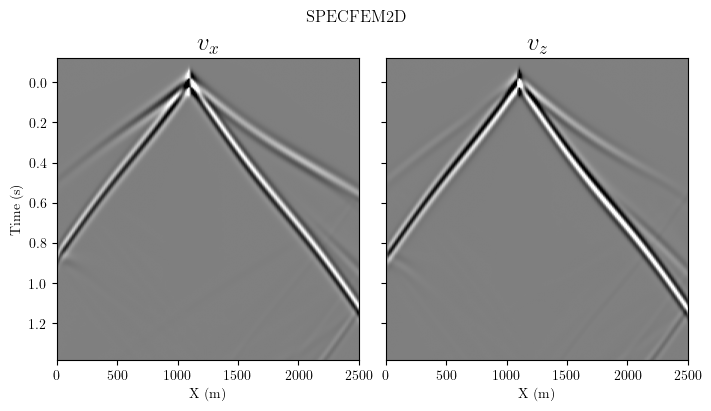

In [55]:
plt.rcParams['figure.figsize'] = [7, 4]
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)
pc=5e-3
t = traceZ[0].to_numpy()
xmin=0
xmax=2500
fig1, (ax1, ax2) = plt.subplots(1, 2, layout='constrained', sharey=True)
fig1.suptitle('SPECFEM2D', fontsize=12)
ax1.set_title('$v_x$', fontsize=18)
ax1.imshow(dataX, cmap='gray', vmin=-pc, vmax=pc, origin='upper', aspect='auto',
           extent=[xmin, xmax, t[-1], t[0]])
ax1.set_ylabel('Time (s)')
ax1.set_xlabel('X (m)')
ax2.set_title('$v_z$', fontsize=18)
ax2.imshow(dataZ, cmap='gray', vmin=-pc, vmax=pc, origin='upper', aspect='auto',
           extent=[xmin, xmax, t[-1], t[0]])
ax2.set_xlabel('X (m)')



if 0:
    fig1.savefig('shot_specfem2d.pdf',bbox_inches='tight')

In [56]:
# save data to file
dt = time[1]-time[0]
np.savez('data_specfem_homotop.npz', vx=dataX, vz=dataZ, dt=dt)